### Longitudinal dynamics of CF virome

In [1]:
### Load packages
import glob

import matplotlib.pyplot as plt
import polars as pl
import seaborn as sns

In [2]:
### Identify candidate subjects
# 1. > 6 month time frame
# 2. At least 3 timepoints
# 3. All sputum samples
# 4. 10E+08 bp read depth per sample

samplesheet = (
    pl.read_csv('cf_longitudinal_samplesheet2.csv').filter(pl.col('bioproject') == 'PRJNA530252')
)

In [3]:
### Load sylph data
data_dir = '../../../results/uhvdb/analyze/prj*/*/*/sylph/profile/*.profile.tsv'
df_lst = []

for file in glob.glob(data_dir):
    sample_id = file.split('/')[-4]
    try:
        df = (
            pl.read_csv(file, separator='\t', columns=['Contig_name', 'Genome_file', 'Taxonomic_abundance', 'Sequence_abundance', 'True_cov'], schema_overrides={
                'Taxonomic_abundance': pl.Float64,
                'Sequence_abundance': pl.Float64,
                'True_cov': pl.Float64
            })
                .with_columns([
                    pl.lit(sample_id).alias('sample'),
                    pl.col('Contig_name').str.split(' ').list[0].alias('contig')
                ])
                [['sample', 'Genome_file', 'Taxonomic_abundance', 'Sequence_abundance', 'True_cov', 'contig']]
        )
        df_lst.append(df)
    except pl.exceptions.NoDataError:
        continue

df = pl.concat(df_lst)

In [4]:
### Merge sylph data with samplesheet
merged = df.join(samplesheet[['sample', 'coassembly_group', 'condition', 'timepoint', 'sample_type']], on='sample')

In [5]:
### merge activity data
activity_data = pl.read_csv('../figure_6/cf_metagenome_virus_activity_data.tsv', separator='\t')
activity_merged = (
    merged
        .join(activity_data[['sample_id', 'num_bp', 'breadth_ratio', 'contig_id', 'mvirs_score', 'propagate_score', 'activity_score']]
            .rename({'sample_id': 'sample', 'contig_id': 'contig'}),
        on=['sample', 'contig'], how='left')
)
activity_data.height

64656

In [6]:
print("Number of samples:", activity_merged.unique(['coassembly_group', 'sample']).height)
print("Number of individuals:", activity_merged.unique(['coassembly_group']).height)

Number of samples: 157
Number of individuals: 30


In [7]:
### filter activity merged to longitudinal groups
activity_merged_long = (
    activity_merged
)
activity_merged_long.height

16951

In [8]:
### merge host genus predictions
host_preds = pl.read_csv('../figure_6/uhvdb_r2025_10_species_combined_host_predictions.tsv', separator='\t')

host= (
    activity_merged_long
        .join(host_preds[['votu_rep', 'species', 'genus', 'family']],
            left_on=['contig'], right_on=['votu_rep'], how='left'
        )
)
host.height

16951

In [9]:
### load host taxonomy
glob_genus = (
    pl.read_csv('../figure_6/globdb_r226_taxonomy.tsv.gz', separator='\t', has_header=False)
        .with_columns([
            pl.col('column_2').str.split(';').list[5].alias('bac_genus'),
            pl.col('column_1').alias('genome_id')
        ])
        .with_columns([
            pl.col('bac_genus').str.replace('g__', '')
        ])
        [['bac_genus', 'genome_id']]
)

glob_df = (
    host
        .with_columns([
            pl.col('Genome_file').str.split('/').list[-1].str.split('.').list[0].alias('genome_id')
        ])
        .join(glob_genus, on='genome_id', how='left')
        [['sample', 'timepoint', 'coassembly_group', 'genome_id', 'contig', 'breadth_ratio', 'activity_score', 'genus', 'bac_genus', 'True_cov', 'Sequence_abundance', 'Taxonomic_abundance']]
)
glob_df.height

16951

In [10]:
### Load ICTV family hits
cf_ictv_hits = pl.read_csv('../figure_6/cf_viruses_ictv_family_hits.tsv', separator='\t').unique(['contig_id', 'Family'])[['contig_id', 'Family']]

ictv = (
    glob_df
        .join(cf_ictv_hits, left_on=['contig'], right_on=['contig_id'], how='left')
)
ictv.height

16951

In [11]:
### Load liffestyle data
cf_bacphlip = (
    pl.read_csv('../figure_6/uhvdb_cf_virus_bacplhip.tsv', separator='\t', columns=['contig_id', 'temperate']).unique('contig_id')
        .with_columns([
            pl.when(pl.col('temperate') > 0.5).then(pl.lit('Temperate')).otherwise(pl.lit('Virulent')).alias('lifestyle')
        ])
)

bacphlip = (
    ictv
        .join(cf_bacphlip, left_on=['contig'], right_on=['contig_id'], how='left')
)
bacphlip.height

16951

In [12]:
### identify max activity scores per contig across all timepoints
max_activity = (
    bacphlip
        .group_by(['coassembly_group', 'contig', 'genome_id'])
        .agg([
            pl.col('activity_score').max().alias('max_activity_score'),
            pl.col('breadth_ratio').max().alias('max_breadth')
        ])
        .with_columns([
            pl.when((pl.col('max_breadth') >= 0.6) & (pl.col('max_activity_score') >= 3)).then(pl.lit('Activity >= 3'))
                .when((pl.col('max_breadth') >= 0.6) & (pl.col('max_activity_score') >= 1)).then(pl.lit('Activity 1-2'))
                .when((pl.col('max_breadth') >= 0.6) & (pl.col('max_activity_score') >= 0)).then(pl.lit('Activity 0'))
                .when(~pl.col('genome_id').str.starts_with('uhvdb')).then(pl.lit('Bacteria'))
                .alias('activity_level')
        ])
)

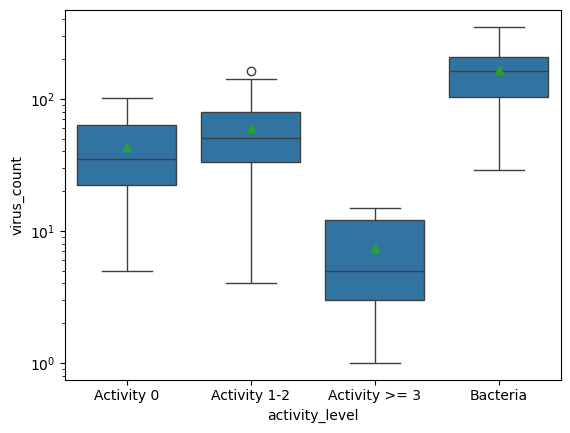

In [13]:
### Count number of viruses per coassembly group by activity level
virus_richness_activity = (
    ictv
        .join(max_activity, on=['coassembly_group', 'contig'], how='left')
        .group_by(['coassembly_group', 'activity_level'])
        .agg(pl.col('contig').n_unique().alias('virus_count'))
        .sort(['coassembly_group', 'activity_level'])
)

sns.boxplot(virus_richness_activity, x='activity_level', y='virus_count', showmeans=True)
plt.yscale('log')
# plt.ylim(1, 200)

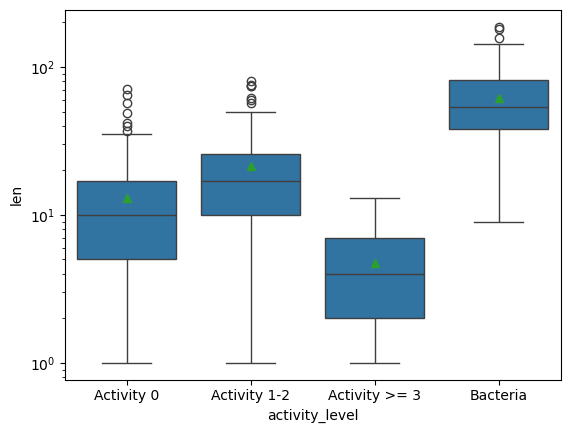

In [14]:
### Count number of viruses per coassembly group by activity level
virus_richness_activity = (
    ictv
        .join(max_activity, on=['coassembly_group', 'contig'], how='left')
        .group_by(['coassembly_group', 'activity_level', 'timepoint'])
        .len()
        .sort(['coassembly_group', 'activity_level'])
)

sns.boxplot(virus_richness_activity, x='activity_level', y='len', showmeans=True)
plt.yscale('log')
# plt.ylim(1, 200)

/tmp/ipykernel_3545/294014183.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


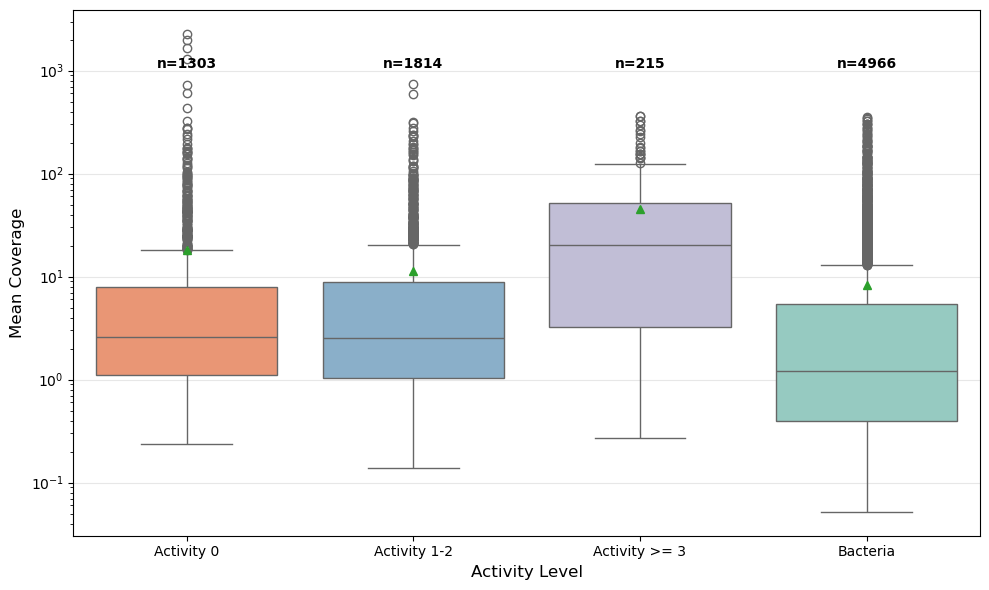

In [15]:
### Calculate virus coverage by activity level
# Calculate persistence for each virus
virus_cov = (
    bacphlip
        .group_by(['coassembly_group', 'contig', 'Family', 'genus'])
        .agg([
            pl.col('True_cov').max().alias('mean_cov')
        ])
        # .filter(pl.col('mean_cov') >= 10)
        .join(max_activity, on=['coassembly_group', 'contig'], how='left')
)


# Visualize persistence by activity level
plt.figure(figsize=(10, 6))
ax = sns.boxplot(
    data=virus_cov.to_pandas(),
    x='activity_level',
    y='mean_cov',
    order=['Activity 0', 'Activity 1-2', 'Activity >= 3', 'Bacteria'],
    palette=['#FC8D62', '#80B1D3', '#BEBADA', '#8DD3C7'],
    showmeans=True
)

# Add counts above each boxplot
activity_order = ['Activity 0', 'Activity 1-2', 'Activity >= 3', 'Bacteria']
for i, activity in enumerate(activity_order):
    count = len(virus_cov.filter(pl.col('activity_level') == activity))
    ax.text(i, 1000, f'n={count}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.xlabel('Activity Level', fontsize=12)
plt.ylabel('Mean Coverage', fontsize=12)
plt.yscale('log')
plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

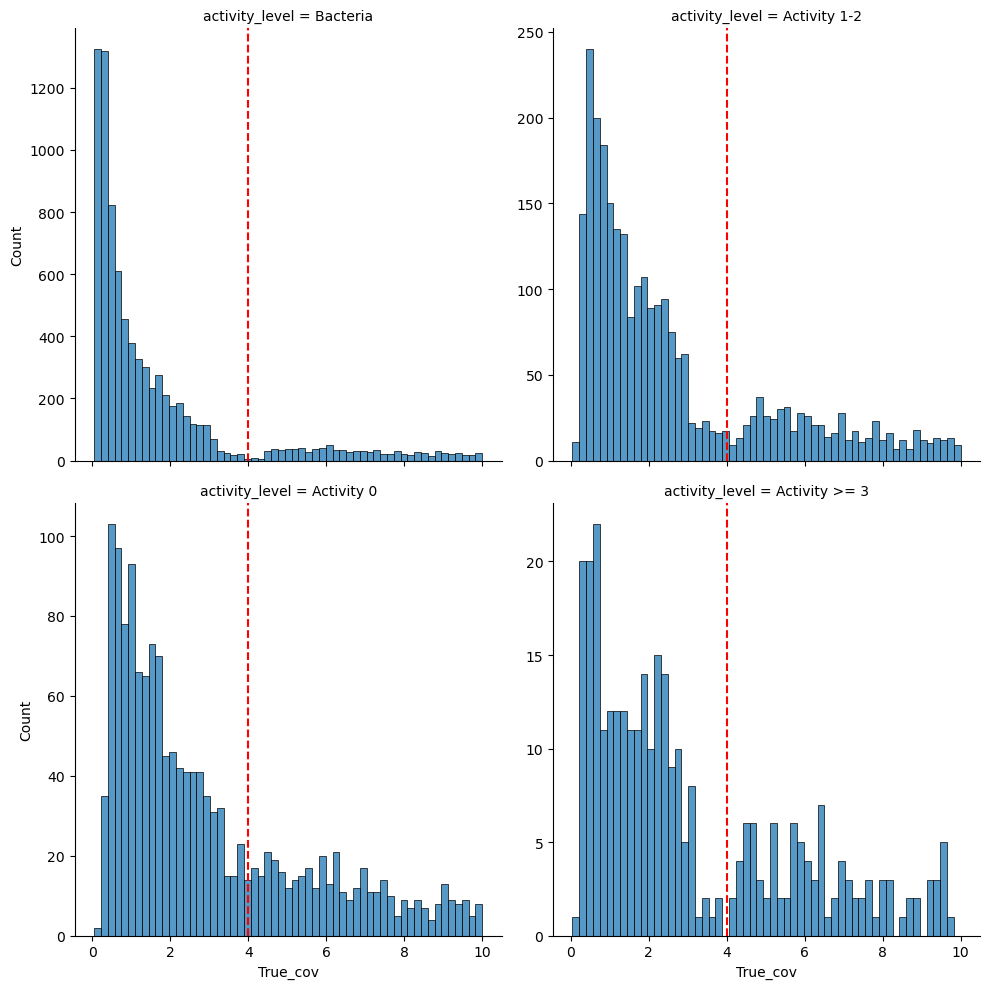

In [16]:
# plot faceted histogram of True_cov by activity_level
data = ictv.join(max_activity, on=['coassembly_group', 'contig'], how='inner').filter(pl.col('True_cov') <= 10)
sns.displot(data, x='True_cov', col='activity_level', col_wrap=2, log_scale=(False, False), facet_kws={'sharey': False})
# draw a vertical line at x=4
for ax in plt.gcf().axes:
    ax.axvline(x=4, color='red', linestyle='--')
plt.show()

/tmp/ipykernel_3545/2835166965.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(
/tmp/ipykernel_3545/2835166965.py:31: UserWarning: 
The palette list has fewer values (3) than needed (4) and will cycle, which may produce an uninterpretable plot.
  ax = sns.boxplot(


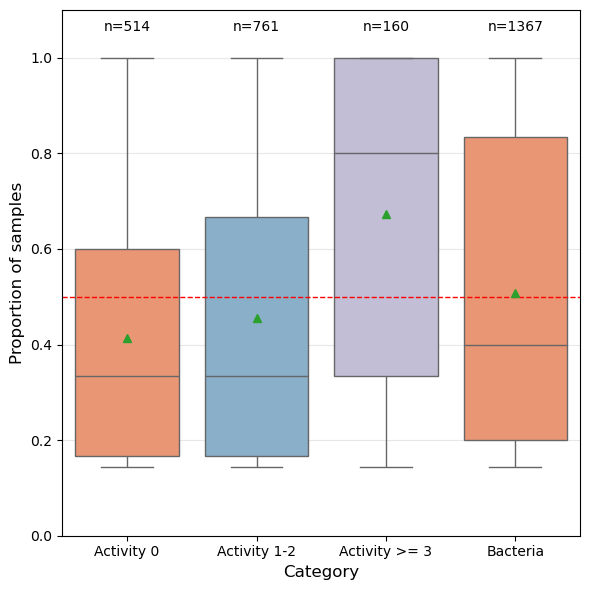

In [17]:
### Calculate virus persistence by activity level

# Get total number of samples per coassembly group
samples_per_group = (
    bacphlip
        .select(['coassembly_group', 'sample'])
        .unique()
        .group_by('coassembly_group')
        .agg(pl.col('sample').n_unique().alias('total_samples'))
)

# Calculate persistence for each virus
persistence = (
    bacphlip
        .group_by(['coassembly_group', 'contig', 'Family', 'genus', 'bac_genus'])
        .agg([
            pl.col('sample').n_unique().alias('samples_detected'),
            pl.col('True_cov').max().alias('max_cov'),
            pl.col('Sequence_abundance').max().alias('max_seq_abundance')
        ])
        .filter(pl.col('max_cov') >= 4)
        .join(samples_per_group, on='coassembly_group')
        .with_columns([
            (pl.col('samples_detected') / pl.col('total_samples')).alias('persistence')
        ])
        .join(max_activity, on=['coassembly_group', 'contig'], how='inner')
)

# Visualize persistence by activity level
plt.figure(figsize=(6, 6))
ax = sns.boxplot(
    data=persistence.to_pandas(),
    x='activity_level',
    y='persistence',
    order=['Activity 0', 'Activity 1-2', 'Activity >= 3', 'Bacteria'],
    palette=['#FC8D62', '#80B1D3', '#BEBADA'],
    showmeans=True
)
# sns.stripplot(
#     data=plot_df.to_pandas(),
#     x='activity_level',
#     y='persistence',
#     order=['Activity 0', 'Activity 1-2', 'Activity >= 3', 'Bacteria'],
#     color='black',
#     alpha=0.5
# )
# Add counts above each boxplot
activity_order = ['Activity 0', 'Activity 1-2', 'Activity >= 3', 'Bacteria']
for i, activity in enumerate(activity_order):
    count = persistence.filter(pl.col('activity_level') == activity).unique(['contig', 'coassembly_group']).height
    ax.text(i, 1.05, f'n={count}', ha='center', va='bottom', fontsize=10,)

plt.xlabel('Category', fontsize=12)
plt.ylabel('Proportion of samples', fontsize=12)
plt.ylim(0,1.1)
plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
# add horizontal line at 0.5
plt.axhline(0.5, color='red', linestyle='--', linewidth=1)
plt.show()

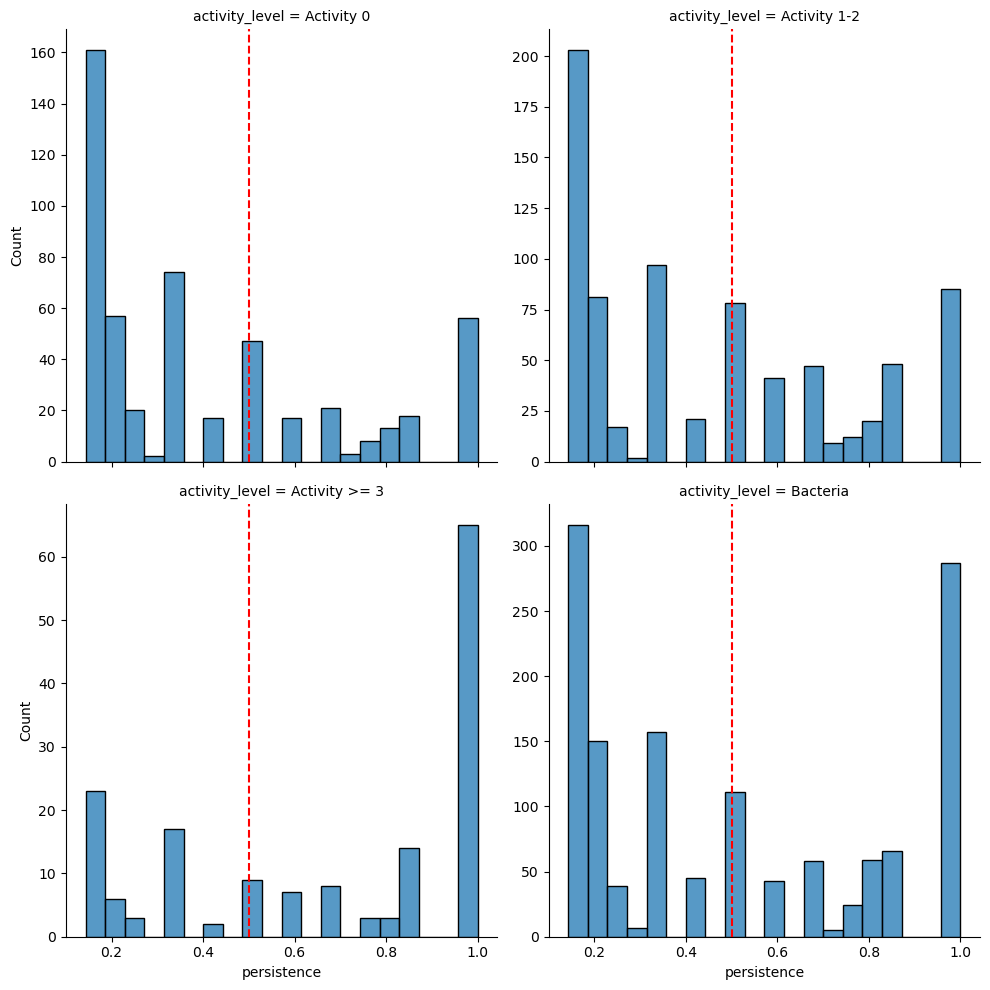

In [18]:
### Histogram of persistence values faceted by activity_level
sns.displot(
    persistence.to_pandas(),
    x='persistence', 
    col='activity_level', 
    col_wrap=2,
    col_order=['Activity 0', 'Activity 1-2', 'Activity >= 3', 'Bacteria'],
    bins=20,
    facet_kws={'sharey': False}
)
plt.tight_layout()
# add vertical line at x=0.5
for ax in plt.gcf().axes:
    ax.axvline(x=0.5, color='red', linestyle='--')
plt.show()

/tmp/ipykernel_3545/1320731507.py:51: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
  .with_columns([
/tmp/ipykernel_3545/1320731507.py:105: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
  .with_columns([


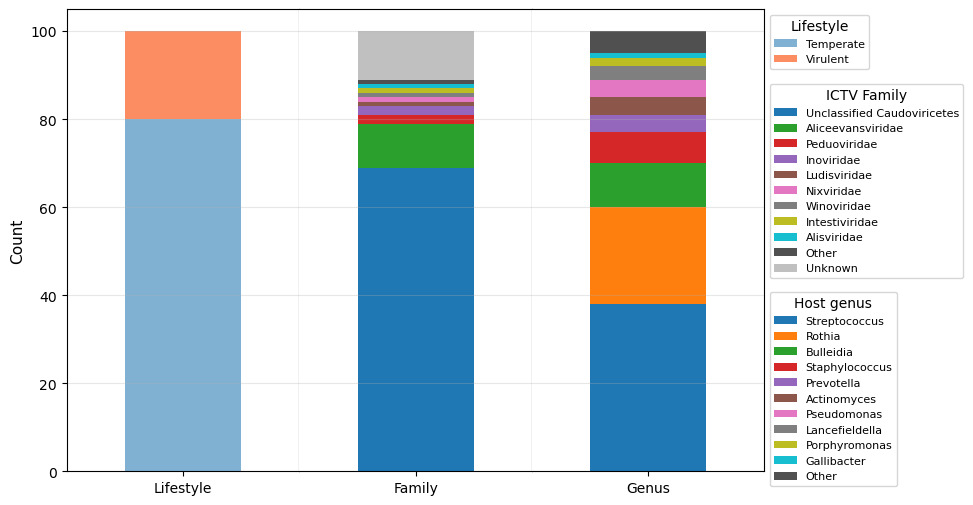

In [19]:
### Stacked barplots of persistent contig characteristics

# Filter for persistent contigs (persistence > 0.5) with activity level >= 3
persistent_contigs = (
    bacphlip
        .join(max_activity, on=['coassembly_group', 'contig'], how='left')
        .join(persistence[['coassembly_group', 'contig', 'persistence']], on=['coassembly_group', 'contig'], how='left')
        .filter(pl.col('persistence') > 0.5)
        .filter(pl.col('activity_level').is_in(['Activity >= 3']))
        .unique(['coassembly_group', 'contig', 'lifestyle', 'genus', 'Family', 'bac_genus', 'activity_level'])
)

# Create figure with 3 subplots (shared y-axis)
fig, axes = plt.subplots(1, 3, figsize=(9, 6), sharey=True)

# Get tab10 colors for all plots
tab10_colors = plt.cm.tab10(range(10))

# 1. Lifestyle stacked barplot
lifestyle_data = (
    persistent_contigs
        .filter(pl.col('lifestyle').is_not_null())
        .group_by(['lifestyle'])
        .agg(pl.len().alias('Lifestyle'))
)

lifestyle_df = lifestyle_data.sort('Lifestyle', descending=True).select(['lifestyle', 'Lifestyle']).to_pandas().set_index('lifestyle').T

lifestyle_df.plot(kind='bar', stacked=True, ax=axes[0], color=['#80B1D3', '#FC8D62'], legend=True)
axes[0].set_xlabel('')
axes[0].set_ylabel('Count', fontsize=11)
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(fontsize=8, bbox_to_anchor=(3, 1), loc='upper left', title='Lifestyle')
axes[0].grid(alpha=0.3, axis='y')

# 2. Top 10 Family stacked barplot with Other and Unknown categories
top_family = (
    persistent_contigs
        .filter(pl.col('Family').is_not_null())
        .group_by('Family')
        .agg(pl.len().alias('count'))
        .sort('count', descending=True)
        .head(10)
        ['Family']
)

# Categorize families into top 10, other, or unknown
family_categorized = (
    persistent_contigs
        .filter(pl.col('activity_level') != 'Bacteria')
        .with_columns([
            pl.when(pl.col('Family').is_null())
                .then(pl.lit('Unknown'))
            .when(pl.col('Family') == 'No family assignment')
                .then(pl.lit('Unknown'))
            .when(pl.col('Family').is_in(top_family))
                .then(pl.col('Family'))
            .otherwise(pl.lit('Other'))
            .alias('family_category')
        ])
)

family_data = (
    family_categorized
        .group_by(['family_category'])
        .agg(pl.len().alias('Family'))
)
family_df = family_data.select(['family_category', 'Family']).to_pandas().set_index('family_category').T

# Define color map with top 10 from tab10, dark grey for Other, light grey for Unknown
family_color_map = {}
for i, family in enumerate(list(top_family)):
    family_color_map[family] = tab10_colors[i]
family_color_map['Other'] = '#505050'  # dark grey
family_color_map['Unknown'] = '#C0C0C0'  # light grey

# Reorder columns to have Unknown and Other at the end
family_col_order = [f for f in list(top_family) if f in family_df.columns] + \
                   (['Other'] if 'Other' in family_df.columns else []) + \
                   (['Unknown'] if 'Unknown' in family_df.columns else [])
family_df = family_df[[c for c in family_col_order if c in family_df.columns]]

family_colors = [family_color_map[col] for col in family_df.columns]
family_df.plot(kind='bar', stacked=True, ax=axes[1], color=family_colors, legend=True)
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(fontsize=8, bbox_to_anchor=(2, 0.85), loc='upper left', title='ICTV Family')
axes[1].grid(alpha=0.3, axis='y')

# 3. Top 10 Host Genus stacked barplot with Other and Unknown categories
top_genus = (
    persistent_contigs
        .filter(pl.col('genus').is_not_null())
        .group_by('genus')
        .agg(pl.len().alias('count'))
        .sort('count', descending=True)
        .head(10)
        ['genus']
)

# Categorize genera into top 10, other, or unknown
genus_categorized = (
    persistent_contigs
        .filter(pl.col('activity_level') != 'Bacteria')
        .with_columns([
            pl.when(pl.col('genus').is_null())
                .then(pl.lit('Unknown'))
            .when(pl.col('genus').is_in(top_genus))
                .then(pl.col('genus'))
            .otherwise(pl.lit('Other'))
            .alias('genus_category')
        ])
)

genus_data = (
    genus_categorized
        .group_by(['genus_category'])
        .agg(pl.len().alias('Genus'))
)

genus_df = genus_data.select(['genus_category', 'Genus']).to_pandas().set_index('genus_category').T

# Define color map with top 10 from tab10, dark grey for Other, light grey for Unknown
color_map = {}
top_genus_list = list(top_genus)
for i, genus in enumerate(top_genus_list):
    color_map[genus] = tab10_colors[i]
color_map['Other'] = '#505050'  # dark grey
color_map['Unknown'] = '#C0C0C0'  # light grey

# Reorder columns to have Unknown and Other at the end
col_order = [g for g in top_genus_list if g in genus_df.columns] + \
            (['Other'] if 'Other' in genus_df.columns else []) + \
            (['Unknown'] if 'Unknown' in genus_df.columns else [])
genus_df = genus_df[[c for c in col_order if c in genus_df.columns]]

colors = [color_map[col] for col in genus_df.columns]
genus_df.plot(kind='bar', stacked=True, ax=axes[2], color=colors, legend=True)
axes[2].set_xlabel('')
axes[2].tick_params(axis='x', rotation=0)
axes[2].legend(fontsize=8, bbox_to_anchor=(1, 0.4), loc='upper left', title='Host genus')
axes[2].grid(alpha=0.3, axis='y')

# Remove spines between subplots for seamless appearance
for i in range(1, 3):
    axes[i].spines['left'].set_visible(False)
    axes[i].tick_params(left=False)

plt.subplots_adjust(wspace=0.0)
plt.show()

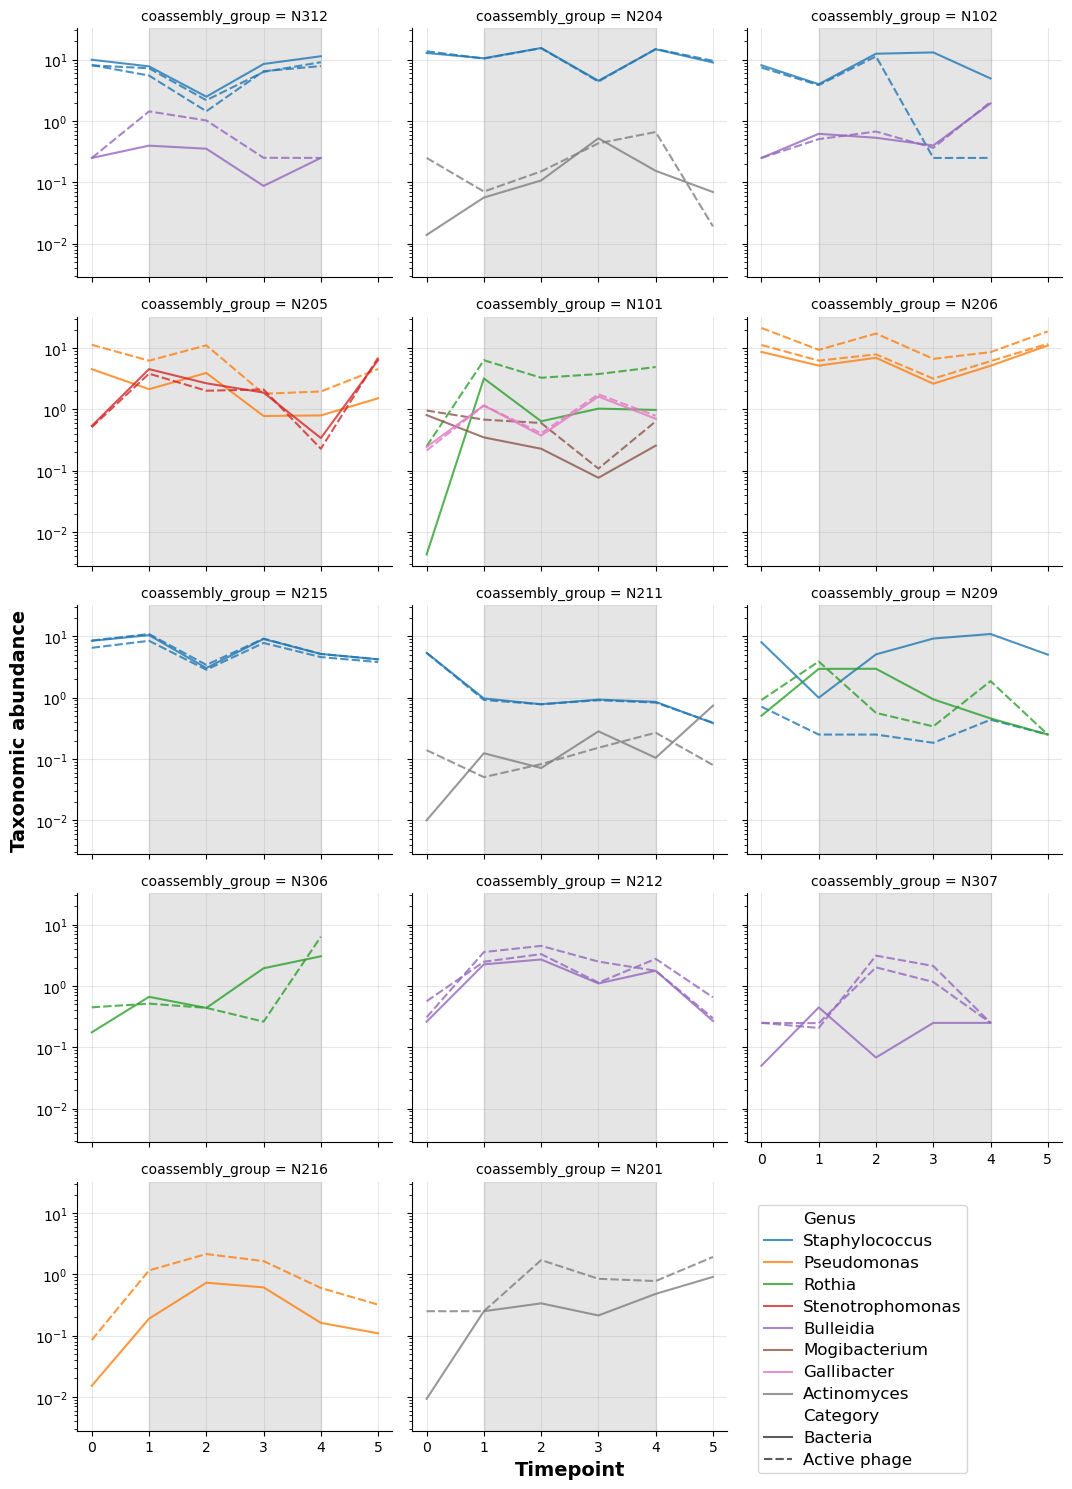

In [40]:
### Lineplot of viral taxonomic abundance over time (normalized to day 0)
# Get minimum date for each coassembly group
min_date_per_group = (
    bacphlip
        .group_by('coassembly_group')
        .agg(pl.col('timepoint').min().alias('min_timepoint'))
)

# Join with min date and calculate days from minimum
time_normalized = (
    bacphlip
        .join(min_date_per_group, on='coassembly_group', how='inner')
        .filter(pl.col('timepoint').is_in(['0', '1', '2', '3', '4', '5']))
        .with_columns([
            # get first character of string and cast as int
            pl.col('timepoint').str.extract(r'(\d+)').cast(pl.Int64).alias('days_from_min'),
        ])
)


# Filter for viruses with high coverage and get their trajectories
virus_traj_filtered = (
    time_normalized
        .join(persistence.select(['coassembly_group', 'contig', 'samples_detected', 'total_samples', 'activity_level']), on=['coassembly_group', 'contig'], how='inner')
        .filter(pl.col('total_samples') >= 5)
        .filter(pl.col('samples_detected') > 2)
        # .filter(~pl.col('activity_level').is_in(['Activity 0', 'Activity 1-2']))
)

# Create all possible combinations and join to fill missing values with 0
all_activity_levels = virus_traj_filtered.select('activity_level').unique()

all_combinations = (
    virus_traj_filtered
        .select(['coassembly_group', 'days_from_min']).unique()
        .join(
            virus_traj_filtered.select(['coassembly_group', 'contig', 'genus', 'bac_genus']).unique(),
            on='coassembly_group',
            how='inner'
        )
        .join(all_activity_levels, how='cross')
)

virus_trajectories = (
    all_combinations
        .join(virus_traj_filtered, on=['coassembly_group', 'contig', 'days_from_min', 'activity_level'], how='left')
        .with_columns([
            pl.col('True_cov').fill_null(0.25),
            pl.col('Taxonomic_abundance').fill_null(0.25),
        ])
        .sort('True_cov', descending=True)
        .unique(subset=['coassembly_group', 'contig', 'days_from_min', 'activity_level'], maintain_order=True)
)

# Remove contigs that are 0.1 at every timepoint within a coassembly group
contigs_to_keep = (
    virus_trajectories
        .group_by(['coassembly_group', 'contig', 'activity_level'])
        .agg(pl.col('True_cov').max().alias('max_true_cov'))
        .filter(pl.col('max_true_cov') > 0.25)
)

# create dict of contig to family
inovirus_set = set(
    virus_traj_filtered
        .filter(pl.col('Family') == 'Inoviridae')
        ['contig']
)

test = (
    virus_trajectories
        .join(contigs_to_keep, on=['coassembly_group', 'contig', 'activity_level'], how='inner')
        .with_columns([
            pl.when(pl.col('contig').is_in(inovirus_set))
                .then(pl.lit('Inoviridae'))
                .otherwise(pl.lit('Other'))
                .alias('family_style')
        ])
)

coassembly_with_bacteria = (
    virus_traj_filtered
        .filter(pl.col('activity_level') == 'Bacteria')
        .select(['coassembly_group'])
        .unique()
)

coassembly_with_virus = (
    virus_traj_filtered
        .filter(pl.col('activity_level').is_in(['Activity >= 3']))
        .select(['coassembly_group'])
        .unique()
)

coassembly_with_both = (
    coassembly_with_virus
        .join(coassembly_with_bacteria, on='coassembly_group', how='inner')
)

test = (
    test
        .join(coassembly_with_both, on='coassembly_group', how='inner')
        .with_columns([
            pl.when(pl.col('bac_genus').is_not_null()).then(pl.col('bac_genus'))
                .when(pl.col('genus').is_not_null()).then(pl.col('genus'))
                .otherwise(pl.lit('Unknown'))
                .alias('Genus')
        ])
)

# filter to genus with both bacteria and phage
genus_with_both = (
    test
        # .filter(pl.col('Genus').is_in(['Pseudomonas', 'Staphylococcus', 'Streptococcus', 'Rothia', 'Bulleidia', 'Prevotella', 'Actinomyces', 'Lancefieldella', 'Porphyromonas', 'Gemella', 'Veillonella', 'Fusobacterium']))
        .filter(pl.col('activity_level') == 'Bacteria')
        .select(['coassembly_group', 'Genus'])
        .unique()
        .join(
            test
            .filter(pl.col('activity_level').is_in(['Activity >= 3']))
                .select(['coassembly_group', 'Genus'])
                .unique(),
            on=['coassembly_group', 'Genus'],
            how='inner'
        )
)

test = (
    test
        .join(genus_with_both, on=['coassembly_group', 'Genus'], how='inner')
)

# Filter out bac_genus groups with more than one contig per coassembly_group
bac_genus_contig_counts = (
    test
        .filter(pl.col('activity_level') == 'Bacteria')
        .select(['coassembly_group', 'bac_genus', 'contig'])
        .unique()
        .group_by(['coassembly_group', 'bac_genus'])
        .agg(pl.col('contig').n_unique().alias('contig_count'))
        .filter(pl.col('contig_count') <= 1)
        .select(['coassembly_group', 'bac_genus'])
)

final = (
    test
        .join(bac_genus_contig_counts, left_on=['coassembly_group', 'Genus'], right_on=['coassembly_group', 'bac_genus'], how='inner', coalesce=True)
        .with_columns([
            pl.col('activity_level').str.replace('Activity >= 3', 'Active phage')
        ])
)


# Create faceted lineplot by coassembly_group
palette = {
    'Bacteria': 'black',
    'Active phage': 'red'
}

g = sns.relplot(
    data=final.rename({'activity_level':'Category', 'family_style':'ICTV Family'}).to_pandas(), 
    x='days_from_min', 
    y='Taxonomic_abundance', 
    col='coassembly_group',
    col_wrap=3,
    kind='line',
    hue='Genus',
    style='Category',
    style_order=['Bacteria','Active phage'],
    # palette=palette,
    height=3,
    aspect=1,
    alpha=0.8,
    units='contig',
    estimator=None
)

# Keep only middle axis titles, bold, larger font
for ax in g.axes.flat:
    ax.set_xlabel('')
    ax.set_ylabel('')

mid_idx = len(g.axes.flat) // 2
g.axes.flat[mid_idx].set_xlabel('Timepoint', fontweight='bold', fontsize=14)
g.axes.flat[mid_idx].set_ylabel('Taxonomic abundance', fontweight='bold', fontsize=14)

for ax in g.axes.flat:
    # Shade timepoint 0-4
    ax.axvspan(1, 4, alpha=0.2, color='gray')
    ax.set_yscale('log')
    ax.grid(alpha=0.3)

# move legend to lower right corner
g._legend.set_bbox_to_anchor((0.9, 0.10))
# add background to legend
g._legend.set_frame_on(True)
# increase legend text size
for text in g._legend.texts:
    text.set_fontsize(12)
plt.tight_layout()

# Fix label placement: show only bottom-middle x label and middle-left y label
for ax in g.axes.flat:
    ax.set_xlabel('')
    ax.set_ylabel('')

visible_axes = [ax for ax in g.axes.flat if ax.get_visible()]
if visible_axes:
    tol = 1e-3

    # Bottom row axes -> choose middle one for x label
    min_y0 = min(ax.get_position().y0 for ax in visible_axes)
    bottom_axes = [ax for ax in visible_axes if abs(ax.get_position().y0 - min_y0) <= tol]
    bottom_axes = sorted(bottom_axes, key=lambda ax: ax.get_position().x0)
    bottom_mid_ax = bottom_axes[len(bottom_axes) // 2]
    bottom_mid_ax.set_xlabel('Timepoint', fontweight='bold', fontsize=14)

    # Left column axes -> choose middle one for y label
    min_x0 = min(ax.get_position().x0 for ax in visible_axes)
    left_axes = [ax for ax in visible_axes if abs(ax.get_position().x0 - min_x0) <= tol]
    left_axes = sorted(left_axes, key=lambda ax: ax.get_position().y0)
    left_mid_ax = left_axes[len(left_axes) // 2]
    left_mid_ax.set_ylabel('Taxonomic abundance', fontweight='bold', fontsize=14)

plt.tight_layout()
plt.show()


<Figure size 640x480 with 0 Axes>

In [33]:
final

coassembly_group,days_from_min,contig,genus,bac_genus,activity_level,sample,timepoint,genome_id,breadth_ratio,activity_score,genus_right,bac_genus_right,True_cov,Sequence_abundance,Taxonomic_abundance,Family,temperate,lifestyle,min_timepoint,samples_detected,total_samples,max_true_cov,family_style,Genus
str,i64,str,str,str,str,str,str,str,f64,f64,str,str,f64,f64,f64,str,f64,str,str,u32,u32,f64,str,str
"""N312""",4,"""SAMEA110349439.contig00009|pro…","""Staphylococcus""",null,"""Activity 0""","""SAMN11310350_SRR8834176_cf""","""4""","""uhvdb_votu_reps""",0.641515,0.0,"""Staphylococcus""",null,434.568,1.3193,15.1636,"""Unclassified Caudoviricetes""",1.0,"""Temperate""","""0""",5,5,434.568,"""Other""","""Staphylococcus"""
"""N208""",1,"""SAMEA10741146_k141_108378""","""Streptococcus""",null,"""Activity >= 3""","""SAMN11310258_SRR8834080_cf""","""1""","""uhvdb_votu_reps""",0.943031,4.0,"""Streptococcus""",null,364.543,14.6843,31.3995,"""No family assignment""",0.45,"""Virulent""","""0""",6,6,364.543,"""Other""","""Streptococcus"""
"""N204""",5,"""SAMN30945741.contig00010|provi…","""Staphylococcus""",null,"""Activity >= 3""","""SAMN11310242_SRR8834063_cf""","""5""","""uhvdb_votu_reps""",0.813561,4.0,"""Staphylococcus""",null,360.688,1.0652,9.6069,"""Unclassified Caudoviricetes""",1.0,"""Temperate""","""0""",6,6,360.688,"""Other""","""Staphylococcus"""
"""N102""",0,"""GCF_001027105_000000000001""",null,"""Staphylococcus""","""Bacteria""","""SAMN11310213_SRR8834034_cf""","""0""","""GCF_001027105""",null,null,null,"""Staphylococcus""",353.348,44.634,8.1095,null,null,null,"""0""",5,5,353.348,"""Other""","""Staphylococcus"""
"""N101""",1,"""GCF_002094975_000000000001""",null,"""Streptococcus""","""Bacteria""","""SAMN11310209_SRR8834030_cf""","""1""","""GCF_002094975""",null,null,null,"""Streptococcus""",349.309,30.5998,15.1477,null,null,null,"""0""",4,5,349.309,"""Other""","""Streptococcus"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""N309""",2,"""GCF_001457615_000000000001""",null,"""Pseudomonas""","""Bacteria""","""SAMN11310341_SRR8834167_cf""","""2""","""GCF_001457615""",null,null,null,"""Pseudomonas""",0.119,0.1518,0.0241,null,null,null,"""0""",4,4,35.673,"""Other""","""Pseudomonas"""
"""N212""",3,"""GCF_001027105_000000000001""",null,"""Staphylococcus""","""Bacteria""","""SAMN11310285_SRR8834108_cf""","""3""","""GCF_001027105""",null,null,null,"""Staphylococcus""",0.1,0.0138,0.0049,null,null,null,"""0""",6,6,84.492,"""Other""","""Staphylococcus"""
"""N306""",3,"""SPIREOTU_01075921__00000000000…",null,"""Streptococcus""","""Bacteria""","""SAMN11310327_SRR8834152_cf""","""3""","""SPIREOTU_01075921""",null,null,null,"""Streptococcus""",0.098,0.0334,0.0133,null,null,null,"""0""",4,5,16.616,"""Other""","""Streptococcus"""


In [21]:
activity_levels = ['Activity 0', 'Activity 1-2', 'Activity >= 3']
num_bac_per_genus = 1000

In [22]:
from itertools import product
import numpy as np
import polars as pl
from scipy.stats import spearmanr



### Lineplot of viral taxonomic abundance over time (normalized to day 0)
# Get minimum date for each coassembly group
min_date_per_group = (
    bacphlip
        .group_by('coassembly_group')
        .agg(pl.col('timepoint').min().alias('min_timepoint'))
)

# Join with min date and calculate days from minimum
time_normalized = (
    bacphlip
        .join(min_date_per_group, on='coassembly_group', how='inner')
        .filter(pl.col('timepoint').is_in(['0', '1', '2', '3', '4', '5']))
        .with_columns([
            # get first character of string and cast as int
            pl.col('timepoint').str.extract(r'(\d+)').cast(pl.Int64).alias('days_from_min'),
        ])
)


# Filter for viruses with high coverage and get their trajectories
virus_traj_filtered = (
    time_normalized
        .join(persistence.select(['coassembly_group', 'contig', 'samples_detected', 'total_samples', 'activity_level']), on=['coassembly_group', 'contig'], how='inner')
        .filter(pl.col('total_samples') >= 3)
        .filter(pl.col('samples_detected') > 2)
        # .filter(~pl.col('activity_level').is_in(['Activity 0', 'Activity 1-2']))
)

# Create all possible combinations and join to fill missing values with 0
all_activity_levels = virus_traj_filtered.select('activity_level').unique()

all_combinations = (
    virus_traj_filtered
        .select(['coassembly_group', 'days_from_min']).unique()
        .join(
            virus_traj_filtered.select(['coassembly_group', 'contig', 'genus', 'bac_genus']).unique(),
            on='coassembly_group',
            how='inner'
        )
        .join(all_activity_levels, how='cross')
)

virus_trajectories = (
    all_combinations
        .join(virus_traj_filtered, on=['coassembly_group', 'contig', 'days_from_min', 'activity_level'], how='left')
        .with_columns([
            pl.col('True_cov').fill_null(0.25),
            pl.col('Taxonomic_abundance').fill_null(0.25),
        ])
        .sort('True_cov', descending=True)
        .unique(subset=['coassembly_group', 'contig', 'days_from_min', 'activity_level'], maintain_order=True)
)

# Remove contigs that are 0.1 at every timepoint within a coassembly group
contigs_to_keep = (
    virus_trajectories
        .group_by(['coassembly_group', 'contig', 'activity_level'])
        .agg(pl.col('True_cov').max().alias('max_true_cov'))
        .filter(pl.col('max_true_cov') > 0.25)
)

# create dict of contig to family
inovirus_set = set(
    virus_traj_filtered
        .filter(pl.col('Family') == 'Inoviridae')
        ['contig']
)

test = (
    virus_trajectories
        .join(contigs_to_keep, on=['coassembly_group', 'contig', 'activity_level'], how='inner')
        .with_columns([
            pl.when(pl.col('contig').is_in(inovirus_set))
                .then(pl.lit('Inoviridae'))
                .otherwise(pl.lit('Other'))
                .alias('family_style')
        ])
)

coassembly_with_bacteria = (
    virus_traj_filtered
        .filter(pl.col('activity_level') == 'Bacteria')
        .select(['coassembly_group'])
        .unique()
)

coassembly_with_virus = (
    virus_traj_filtered
        .filter(pl.col('activity_level').is_in(activity_levels))
        .select(['coassembly_group'])
        .unique()
)

coassembly_with_both = (
    coassembly_with_virus
        .join(coassembly_with_bacteria, on='coassembly_group', how='inner')
)

test = (
    test
        .join(coassembly_with_both, on='coassembly_group', how='inner')
        .with_columns([
            pl.when(pl.col('bac_genus').is_not_null()).then(pl.col('bac_genus'))
                .when(pl.col('genus').is_not_null()).then(pl.col('genus'))
                .otherwise(pl.lit('Unknown'))
                .alias('Genus')
        ])
)

# filter to genus with both bacteria and phage
genus_with_both = (
    test
        # .filter(pl.col('Genus').is_in(['Pseudomonas', 'Staphylococcus', 'Streptococcus', 'Rothia', 'Bulleidia', 'Prevotella', 'Actinomyces', 'Lancefieldella', 'Porphyromonas', 'Gemella', 'Veillonella', 'Fusobacterium']))
        .filter(pl.col('activity_level') == 'Bacteria')
        .select(['coassembly_group', 'Genus'])
        .unique()
        .join(
            test
            .filter(pl.col('activity_level').is_in(activity_levels))
                .select(['coassembly_group', 'Genus'])
                .unique(),
            on=['coassembly_group', 'Genus'],
            how='inner'
        )
)

test = (
    test
        .join(genus_with_both, on=['coassembly_group', 'Genus'], how='inner')
)

# Filter out bac_genus groups with more than one contig per coassembly_group
bac_genus_contig_counts = (
    test
        .filter(pl.col('activity_level') == 'Bacteria')
        .select(['coassembly_group', 'bac_genus', 'contig'])
        .unique()
        .group_by(['coassembly_group', 'bac_genus'])
        .agg(pl.col('contig').n_unique().alias('contig_count'))
        .filter(pl.col('contig_count') <= num_bac_per_genus)
        .select(['coassembly_group', 'bac_genus'])
)

final = (
    test
        .join(bac_genus_contig_counts, left_on=['coassembly_group', 'Genus'], right_on=['coassembly_group', 'bac_genus'], how='inner', coalesce=True)
)

# Expecting `test` with columns: coassembly_group, Genus, contig, activity_level, days_from_min, True_cov
# Split bacteria and phage contigs
bacteria = (
    final
    .filter(pl.col("activity_level") == "Bacteria")
    .select(["coassembly_group", "Genus", "contig", "days_from_min", "Taxonomic_abundance", "True_cov"])
    .rename({"contig": "bac_contig", "Taxonomic_abundance": "bac_abundance", "True_cov": "bac_cov"})
)

phage = (
    final
    .filter(pl.col("activity_level").is_in(activity_levels))
    .select(["coassembly_group", "Genus", "contig", "days_from_min", "Taxonomic_abundance", "True_cov", "activity_level"])
    .rename({"contig": "phage_contig", "Taxonomic_abundance": "phage_abundance", "True_cov": "phage_cov"})
)

# Join by coassembly_group, Genus, and time so trajectories align
paired = (
    bacteria.join(
        phage,
        on=["coassembly_group", "Genus", "days_from_min"],
        how="inner"
    )
)

# Compute Spearman for each phage-bacteria contig pair within a subject/genus
def spearman_from_lists(s):
    x = np.array(s["bac_cov_list"])
    y = np.array(s["phage_cov_list"])
    if len(x) < 2 or np.all(x == x[0]) or np.all(y == y[0]):
        return {"spearman_rho": np.nan, "spearman_pval": np.nan}
    rho, pval = spearmanr(x, y)
    return {"spearman_rho": rho, "spearman_pval": pval}

spearman_df = (
    paired
    .group_by(["coassembly_group", "Genus", "bac_contig", "phage_contig", "activity_level"])
    .agg([
        pl.col("bac_abundance").alias("bac_cov_list"),
        pl.col("phage_abundance").alias("phage_cov_list"),
        pl.len().alias("n_timepoints"),
    ])
    .with_columns(
        pl.struct(["bac_cov_list", "phage_cov_list"])
        .map_elements(spearman_from_lists)
        .alias("stats")
    )
    .unnest("stats")
    .drop(["bac_cov_list", "phage_cov_list"])
    .sort(["coassembly_group", "Genus", "spearman_rho"], descending=[False, False, True])
)


/tmp/ipykernel_3545/2270368952.py:20: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


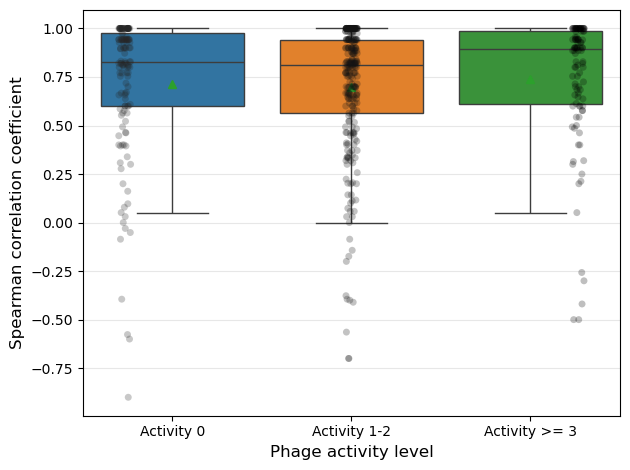

In [23]:
top_spearman_per_phage = (
    spearman_df
            .group_by(['coassembly_group', 'phage_contig', 'Genus', 'activity_level'])
            .agg([
                pl.col('spearman_pval').min(),
                pl.col('spearman_rho').max()
            ])
)

# create a boxplot of spearman rho by activity level
sns.boxplot(
    top_spearman_per_phage,
    x='activity_level',
    y='spearman_rho',
    hue='activity_level',
    order=activity_levels,
    showmeans=True,
    showfliers=False
)
sns.stripplot(
    top_spearman_per_phage,
    x='activity_level',
    y='spearman_rho',
    hue='activity_level',
    order=activity_levels,
    dodge=True,
    color='black',
    alpha=0.25,
)
plt.xlabel('Phage activity level', fontsize=12)
plt.ylabel('Spearman correlation coefficient', fontsize=12)
plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

In [24]:
highest_rho_per_phage = (
    spearman_df
    .group_by(['coassembly_group', 'phage_contig', 'Genus', 'activity_level'])
    .agg([
        pl.col('spearman_rho').max().alias('max_spearman_rho'),
    ])
    .join(
        spearman_df,
        on=['coassembly_group', 'phage_contig', 'Genus', 'activity_level'],
        how='inner'
    )
    .filter(pl.col('spearman_rho') == pl.col('max_spearman_rho'))
    .unique(subset=['coassembly_group', 'phage_contig', 'Genus', 'activity_level'], maintain_order=True)
)

# calculate proportion with p-value <= 0.05 for each activity level
(
    highest_rho_per_phage
    .filter(pl.col('spearman_rho') > 0)
    .group_by('activity_level')
    .agg([
        pl.col('spearman_pval').filter(pl.col('spearman_pval') <= 0.05).count().alias('sig_count'),
        pl.col('spearman_pval').count().alias('total_count'),
        (pl.col('spearman_pval').filter(pl.col('spearman_pval') <= 0.05).count() / pl.col('spearman_pval').count()).alias('proportion_sig')
    ])
)

activity_level,sig_count,total_count,proportion_sig
str,u32,u32,f64
"""Activity 0""",72,125,0.576
"""Activity >= 3""",61,99,0.616162
"""Activity 1-2""",121,251,0.482072


In [25]:
highest_rho_per_phage.filter(pl.col('spearman_rho') > 0).filter(pl.col('activity_level') == 'Activity >= 3')['spearman_rho'].mean()

0.7991193702875667

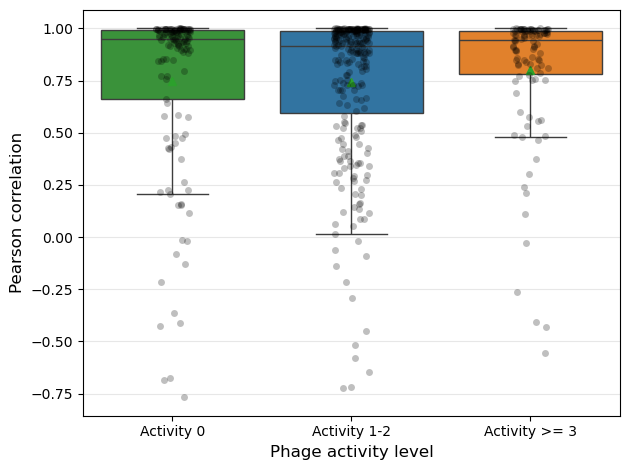

In [26]:
from scipy.stats import pearsonr

# Compute Pearson correlation per phage-bacteria pair
def pearson_from_lists(s):
    x = np.array(s["bac_cov_list"])
    y = np.array(s["phage_cov_list"])
    if len(x) < 2 or np.all(x == x[0]) or np.all(y == y[0]):
        return {"pearson_r": np.nan, "pearson_pval": np.nan}
    r, pval = pearsonr(x, y)
    return {"pearson_r": r, "pearson_pval": pval}

pearson_df = (
    paired
    .group_by(["coassembly_group", "Genus", "bac_contig", "phage_contig", "activity_level"])
    .agg([
        pl.col("bac_abundance").alias("bac_cov_list"),
        pl.col("phage_abundance").alias("phage_cov_list"),
        pl.len().alias("n_timepoints"),
    ])
    .with_columns(
        pl.struct(["bac_cov_list", "phage_cov_list"])
        .map_elements(pearson_from_lists)
        .alias("stats")
    )
    .unnest("stats")
    .drop(["bac_cov_list", "phage_cov_list"])
)

# Boxplot of Pearson correlation by activity level
top_pearson_per_phage = (
    pearson_df
            .group_by(['coassembly_group', 'phage_contig', 'Genus', 'activity_level'])
            .agg([
                pl.col('pearson_pval').min(),
                pl.col('pearson_r').max()
            ])
)
pearson_plot = top_pearson_per_phage.select(["activity_level", "pearson_r"]).to_pandas()

sns.boxplot(
    data=pearson_plot,
    x="activity_level",
    y="pearson_r",
    order=activity_levels,
    hue='activity_level',
    showmeans=True,
    showfliers=False
 )
sns.stripplot(
    data=pearson_plot,
    x="activity_level",
    y="pearson_r",
    order=activity_levels,
    color="black",
    alpha=0.25,
    dodge=False
 )
plt.xlabel("Phage activity level", fontsize=12)
plt.ylabel("Pearson correlation", fontsize=12)
plt.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

In [27]:
highest_r_per_phage = (
    pearson_df
    .group_by(['coassembly_group', 'phage_contig', 'Genus', 'activity_level'])
    .agg([
        pl.col('pearson_r').max().alias('max_pearson_r'),
    ])
    .join(
        pearson_df,
        on=['coassembly_group', 'phage_contig', 'Genus', 'activity_level'],
        how='inner'
    )
    .filter(pl.col('pearson_r') == pl.col('max_pearson_r'))
    .unique(subset=['coassembly_group', 'phage_contig', 'Genus', 'activity_level'], maintain_order=True)
)

# calculate proportion with p-value <= 0.05 for each activity level
(
    highest_r_per_phage
    .filter(pl.col('pearson_r') > 0)
    .group_by('activity_level')
    .agg([
        pl.col('pearson_pval').filter(pl.col('pearson_pval') <= 0.05).count().alias('sig_count'),
        pl.col('pearson_pval').count().alias('total_count'),
        (pl.col('pearson_pval').filter(pl.col('pearson_pval') <= 0.05).count() / pl.col('pearson_pval').count()).alias('proportion_sig')
    ])
)

activity_level,sig_count,total_count,proportion_sig
str,u32,u32,f64
"""Activity 0""",91,122,0.745902
"""Activity >= 3""",68,99,0.686869
"""Activity 1-2""",159,251,0.633466


Average virus-to-bacteria coverage ratios for significant Spearman correlations:
shape: (3, 5)
┌────────────────┬────────────┬──────────────┬───────────┬────────────────┐
│ activity_level ┆ mean_ratio ┆ median_ratio ┆ std_ratio ┆ n_observations │
│ ---            ┆ ---        ┆ ---          ┆ ---       ┆ ---            │
│ str            ┆ f64        ┆ f64          ┆ f64       ┆ u32            │
╞════════════════╪════════════╪══════════════╪═══════════╪════════════════╡
│ Activity 0     ┆ 4.685989   ┆ 1.0          ┆ 49.862728 ┆ 403            │
│ Activity 1-2   ┆ 2.537375   ┆ 1.0          ┆ 14.214097 ┆ 664            │
│ Activity >= 3  ┆ 3.19581    ┆ 1.066325     ┆ 12.172324 ┆ 341            │
└────────────────┴────────────┴──────────────┴───────────┴────────────────┘


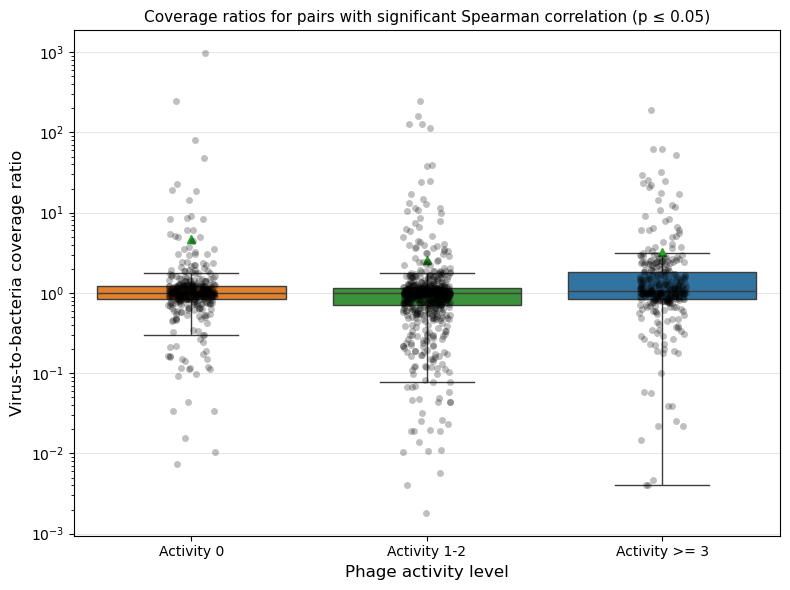

In [28]:
# Calculate average virus-to-bacteria coverage ratio for significant Pearson correlations

# Get significant pairs (p-value <= 0.05)
significant_pairs = (
    highest_rho_per_phage
    .filter(pl.col('spearman_pval') <= 0.05)
    .select(['coassembly_group', 'phage_contig', 'bac_contig', 'Genus', 'activity_level'])
)

# Join with paired data to get coverage values
coverage_ratios = (
    paired
    .join(significant_pairs, on=['coassembly_group', 'phage_contig', 'bac_contig', 'Genus'], how='inner')
    .with_columns([
        (pl.col('phage_cov') / pl.col('bac_cov')).alias('virus_to_bacteria_ratio')
    ])
    .filter(pl.col('virus_to_bacteria_ratio').is_finite())  # Remove inf/nan values
)

# Calculate average ratio per activity level
avg_ratio_by_activity = (
    coverage_ratios
    .group_by(['activity_level'])
    .agg([
        pl.col('virus_to_bacteria_ratio').mean().alias('mean_ratio'),
        pl.col('virus_to_bacteria_ratio').median().alias('median_ratio'),
        pl.col('virus_to_bacteria_ratio').std().alias('std_ratio'),
        pl.len().alias('n_observations')
    ])
    .sort('activity_level')
)

print("Average virus-to-bacteria coverage ratios for significant Spearman correlations:")
print(avg_ratio_by_activity)

# Also calculate per phage-bacteria pair
avg_ratio_per_pair = (
    coverage_ratios
    .group_by(['coassembly_group', 'phage_contig', 'bac_contig', 'Genus', 'activity_level'])
    .agg([
        pl.col('virus_to_bacteria_ratio').mean().alias('mean_ratio'),
        pl.col('virus_to_bacteria_ratio').median().alias('median_ratio'),
        pl.len().alias('n_timepoints')
    ])
)

# Boxplot of ratios by activity level
plt.figure(figsize=(8, 6))
sns.boxplot(
    data=coverage_ratios,
    x='activity_level',
    y='virus_to_bacteria_ratio',
    order=activity_levels,
    hue='activity_level',
    showmeans=True,
    showfliers=False
)
sns.stripplot(
    data=coverage_ratios,
    x='activity_level',
    y='virus_to_bacteria_ratio',
    order=activity_levels,
    color='black',
    alpha=0.25,
)
plt.yscale('log')
plt.xlabel('Phage activity level', fontsize=12)
plt.ylabel('Virus-to-bacteria coverage ratio', fontsize=12)
plt.title('Coverage ratios for pairs with significant Spearman correlation (p ≤ 0.05)', fontsize=11)
plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

Average virus-to-bacteria coverage ratios for significant Spearman correlations:
shape: (3, 5)
┌────────────────┬────────────┬──────────────┬───────────┬────────────────┐
│ activity_level ┆ mean_ratio ┆ median_ratio ┆ std_ratio ┆ n_observations │
│ ---            ┆ ---        ┆ ---          ┆ ---       ┆ ---            │
│ str            ┆ f64        ┆ f64          ┆ f64       ┆ u32            │
╞════════════════╪════════════╪══════════════╪═══════════╪════════════════╡
│ Activity 0     ┆ 4.685989   ┆ 1.0          ┆ 49.862728 ┆ 403            │
│ Activity 1-2   ┆ 2.537375   ┆ 1.0          ┆ 14.214097 ┆ 664            │
│ Activity >= 3  ┆ 3.19581    ┆ 1.066325     ┆ 12.172324 ┆ 341            │
└────────────────┴────────────┴──────────────┴───────────┴────────────────┘


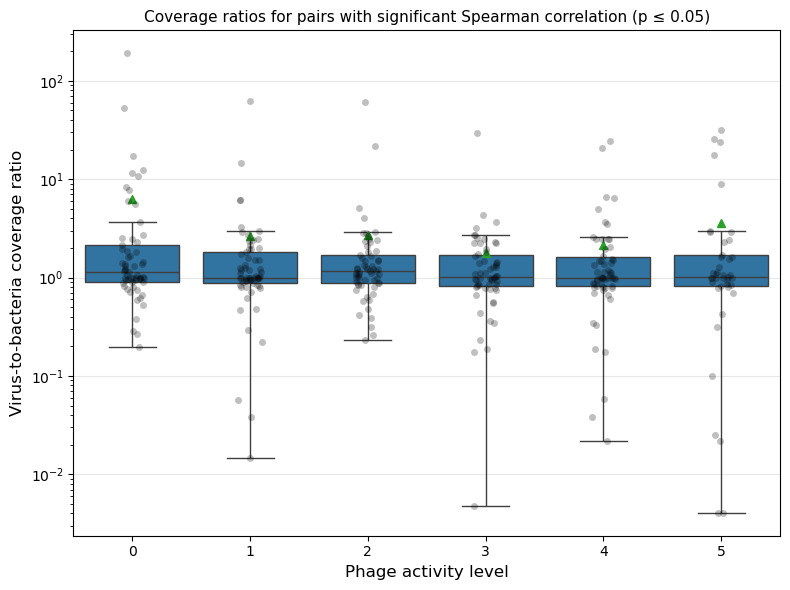

In [29]:
# Calculate average virus-to-bacteria coverage ratio for significant Pearson correlations

# Get significant pairs (p-value <= 0.05)
significant_pairs = (
    highest_rho_per_phage
    .filter(pl.col('spearman_pval') <= 0.05)
    .select(['coassembly_group', 'phage_contig', 'bac_contig', 'Genus', 'activity_level'])
)

# Join with paired data to get coverage values
coverage_ratios = (
    paired
    .join(significant_pairs, on=['coassembly_group', 'phage_contig', 'bac_contig', 'Genus'], how='inner')
    .with_columns([
        (pl.col('phage_cov') / pl.col('bac_cov')).alias('virus_to_bacteria_ratio')
    ])
    .filter(pl.col('virus_to_bacteria_ratio').is_finite())  # Remove inf/nan values
)

# Calculate average ratio per activity level
avg_ratio_by_activity = (
    coverage_ratios
    .group_by(['activity_level'])
    .agg([
        pl.col('virus_to_bacteria_ratio').mean().alias('mean_ratio'),
        pl.col('virus_to_bacteria_ratio').median().alias('median_ratio'),
        pl.col('virus_to_bacteria_ratio').std().alias('std_ratio'),
        pl.len().alias('n_observations')
    ])
    .sort('activity_level')
)

print("Average virus-to-bacteria coverage ratios for significant Spearman correlations:")
print(avg_ratio_by_activity)

# Also calculate per phage-bacteria pair
avg_ratio_per_pair = (
    coverage_ratios
    .group_by(['coassembly_group', 'phage_contig', 'bac_contig', 'Genus', 'activity_level'])
    .agg([
        pl.col('virus_to_bacteria_ratio').mean().alias('mean_ratio'),
        pl.col('virus_to_bacteria_ratio').median().alias('median_ratio'),
        pl.len().alias('n_timepoints')
    ])
)

# Boxplot of ratios by activity level
plt.figure(figsize=(8, 6))
sns.boxplot(
    data=coverage_ratios.filter(pl.col('activity_level').is_in(['Activity >= 3'])),
    x='days_from_min',
    y='virus_to_bacteria_ratio',
    showmeans=True,
    showfliers=False
)
sns.stripplot(
    data=coverage_ratios.filter(pl.col('activity_level').is_in(['Activity >= 3'])),
    x='days_from_min',
    y='virus_to_bacteria_ratio',
    color='black',
    alpha=0.25,
)
plt.yscale('log')
plt.xlabel('Phage activity level', fontsize=12)
plt.ylabel('Virus-to-bacteria coverage ratio', fontsize=12)
plt.title('Coverage ratios for pairs with significant Spearman correlation (p ≤ 0.05)', fontsize=11)
plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

In [30]:
coverage_ratios.unique(['coassembly_group', 'phage_contig', 'bac_contig', 'Genus', 'activity_level', 'days_from_min']).filter(pl.col('coassembly_group') == 'N214').filter(pl.col('days_from_min') == 0)

coassembly_group,Genus,bac_contig,days_from_min,bac_abundance,bac_cov,phage_contig,phage_abundance,phage_cov,activity_level,activity_level_right,virus_to_bacteria_ratio
str,str,str,i64,f64,f64,str,f64,f64,str,str,f64
"""N214""","""Pseudomonas""","""GCF_001457615_000000000001""",0,2.3563,53.565,"""SAMN26931481.contig00040|provi…",2.0098,45.687,"""Activity 0""","""Activity 0""",0.852926
"""N214""","""Streptococcus""","""MOTU40_021422_000000000001""",0,0.7458,16.954,"""SAMN11310297_SRR8834121_cf_k25…",0.7002,15.918,"""Activity >= 3""","""Activity >= 3""",0.938893
"""N214""","""Streptococcus""","""MOTU40_021081_000000000001""",0,1.6633,37.81,"""SRS019494_a1_ct15886_vs1@Myovi…",1.6633,37.81,"""Activity 1-2""","""Activity 1-2""",1.0
"""N214""","""Pseudomonas""","""GCF_001457615_000000000001""",0,2.3563,53.565,"""IMGVR_UViG_2684622812_000001|2…",4.2967,97.677,"""Activity 1-2""","""Activity 1-2""",1.823523
"""N214""","""Pseudomonas""","""GCF_001457615_000000000001""",0,2.3563,53.565,"""SAMEA5312836.contig00123""",1.7326,39.386,"""Activity 1-2""","""Activity 1-2""",0.735294
"""N214""","""Streptococcus""","""MOTU40_021081_000000000001""",0,1.6633,37.81,"""SAMN11310324_SRR8834149_cf_k25…",0.0231,0.525,"""Activity 1-2""","""Activity 1-2""",0.013885
"""N214""","""Pseudomonas""","""GCF_001457615_000000000001""",0,2.3563,53.565,"""SAMN24547460.contig00012|provi…",2.8414,64.593,"""Activity 0""","""Activity 0""",1.205881
"""N214""","""Streptococcus""","""MOTU40_006753_000000000001""",0,0.6641,15.096,"""UHGV-0210681""",0.6472,14.712,"""Activity >= 3""","""Activity >= 3""",0.974563


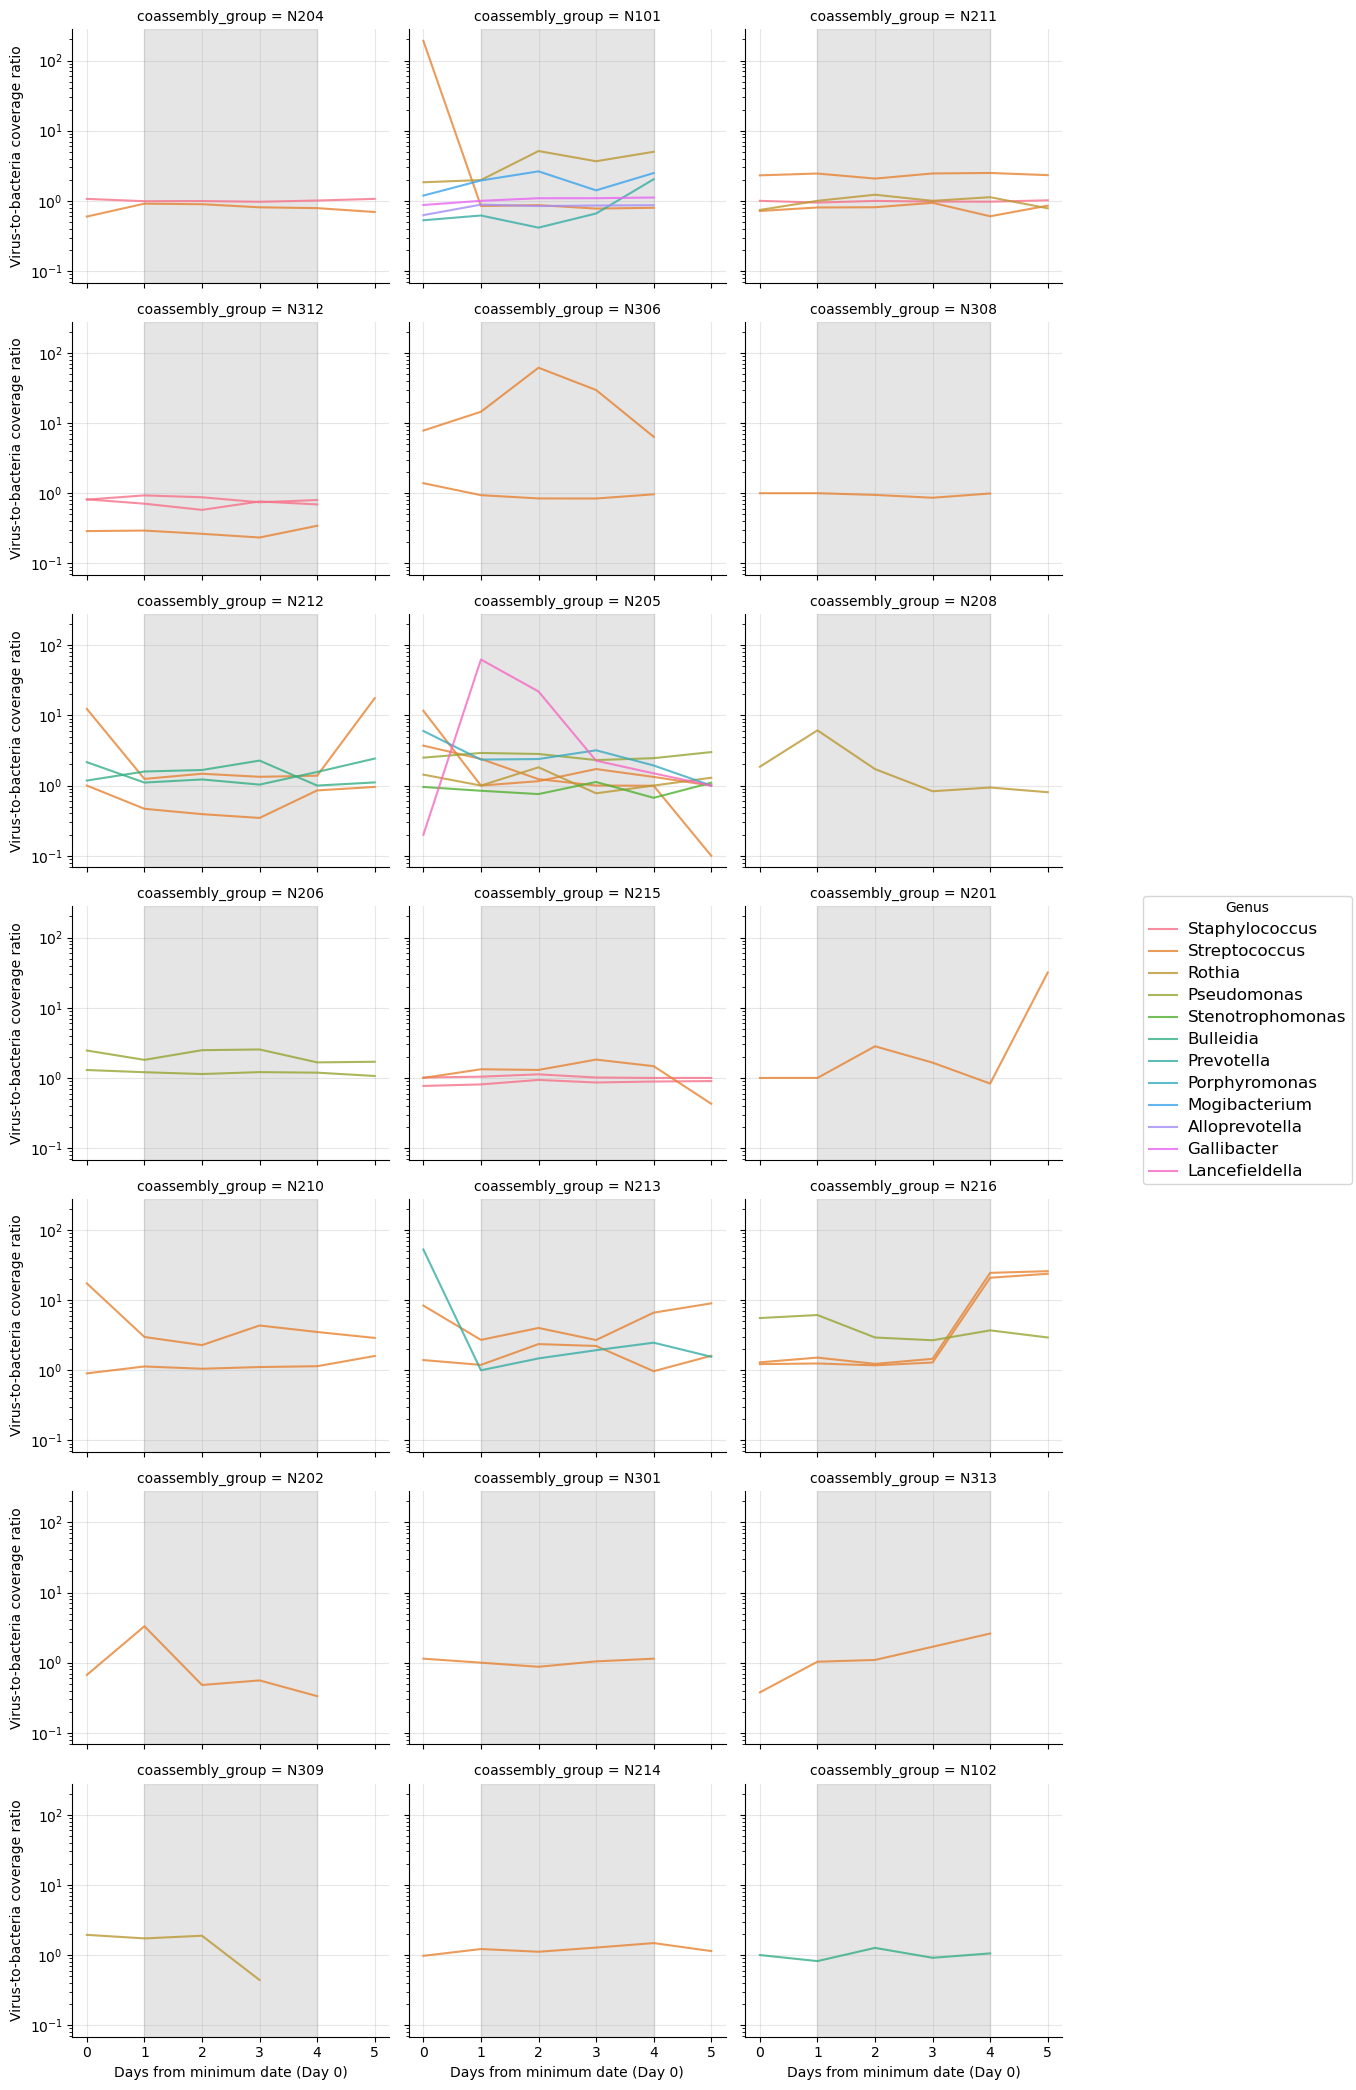

In [31]:
phages_to_keep = (
    coverage_ratios
    .group_by(['coassembly_group', 'phage_contig'])
    .agg([
        pl.col('phage_cov').filter(pl.col('phage_cov') >= 4).count().alias('n_high_cov_samples')
    ])
    .filter(pl.col('n_high_cov_samples') >= 3)
    .select(['coassembly_group', 'phage_contig'])
)

coverage_ratios_filtered = (
    coverage_ratios
    .join(phages_to_keep, on=['coassembly_group', 'phage_contig'], how='inner')
)

g = sns.relplot(
    data=coverage_ratios_filtered.filter(pl.col('activity_level') == 'Activity >= 3').rename({'activity_level':'Category'}), 
    x='days_from_min', 
    y='virus_to_bacteria_ratio', 
    col='coassembly_group',
    col_wrap=3,
    kind='line',
    hue='Genus',
    # style='Category',
    # palette=palette,
    height=3,
    aspect=1,
    alpha=0.8,
    units='phage_contig',
    estimator=None
)

g.set_axis_labels('Days from minimum date (Day 0)', 'Virus-to-bacteria coverage ratio')
for ax in g.axes.flat:
    # Shade timepoint 0-4
    ax.axvspan(1, 4, alpha=0.2, color='gray')
    ax.set_yscale('log')
    # ax.set_ylim(0.1, 10)
    ax.grid(alpha=0.3)

# move legend to the right of the figure
g._legend.set_bbox_to_anchor((1.05, 0.5))
g._legend.set_loc('center left')
# add background to legend
g._legend.set_frame_on(True)
# increase legend text size
for text in g._legend.texts:
    text.set_fontsize(12)
plt.tight_layout()
plt.show()